# BANKING77 EDA

Before training any model, we first get to know the data. This notebook checks the split sizes, label coverage, missing values, duplicate queries, and typical query length. The official test set stays untouched throughout.

## How to run this notebook

- Use the `nlp-banking` Conda environment.
- Run the cells from top to bottom.
- The first data-loading cell may download BANKING77 from Hugging Face.
- The observations and figures produced here are the evidence used by the later experiments and report.

## Why this step matters

The other example notebook uses EDA to justify a causal language-model objective. Here, EDA serves a different purpose: it confirms that BANKING77 is a balanced 77-intent classification problem and helps us anticipate confusing intent pairs before evaluating models.

## Reproducibility

The validation split is created from the original training split with seed `42`. The official test split is not used for model selection.

## Course connection

This follows the course emphasis on understanding the dataset before selecting a model. The classification-oriented Transformer notebook in `references/course/Transformers_classification.ipynb` is the closest course example for this task.

## Step 1 — Load and split BANKING77

**What this does:** loads the public dataset and creates a reproducible validation split.

**Why:** the validation set is used during development, while the official test set must remain untouched until final evaluation.


In [1]:
# Load the dataset once so every later notebook uses the same split.
# The validation split comes from training data; the official test data is preserved.
# Add the repository root so the notebook can import reusable project code.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.data.load_data import load_banking77
dataset = load_banking77(validation_size=0.1, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9002
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1001
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

## Step 2 — Check data quality

**What this does:** checks split sizes, labels, missing values, and duplicate queries.

**Why:** these checks tell us whether the data is safe to use and whether a model might be affected by duplicate examples or missing fields.


In [2]:
# Convert the splits to pandas because descriptive statistics and plots are easier to read there.
# We inspect every split size and verify that text and labels are complete.
# Convert the dataset to pandas only for the descriptive checks and plots.
import pandas as pd
train = dataset["train"].to_pandas()
validation = dataset["validation"].to_pandas()
test = dataset["test"].to_pandas()
print({"train": len(train), "validation": len(validation), "test": len(test), "labels": train["label"].nunique()})
print("missing:", train.isna().sum().to_dict())
print("duplicates:", int(train["text"].duplicated().sum()))

{'train': 9002, 'validation': 1001, 'test': 3080, 'labels': 77}
missing: {'text': 0, 'label': 0}
duplicates: 0


## Step 3 — Create useful EDA figures

**What this does:** saves the class distribution and query-length figures used in the report.

**Why:** class balance and text length affect model difficulty, memory use, and interpretation of errors.


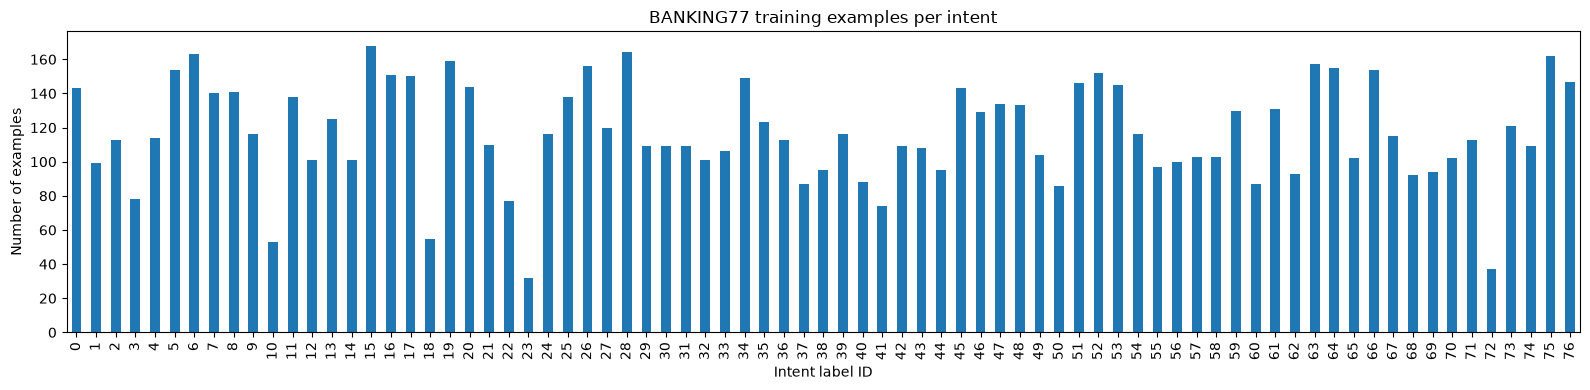

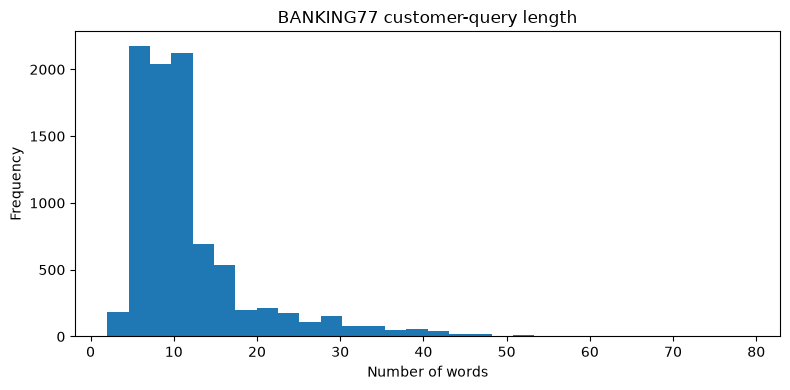

In [3]:
# Save the two figures used in the report so the visual evidence travels with the notebook.
# Label counts show class balance; word lengths show how short or long the queries are.
# Save the two plots used in the report: label balance and query length.
import matplotlib.pyplot as plt

figures_dir = Path.cwd().parent / "figures"
figures_dir.mkdir(exist_ok=True)

train["word_length"] = train["text"].str.split().str.len()

ax = train["label"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(16, 4),
    title="BANKING77 training examples per intent",
)
ax.set_xlabel("Intent label ID")
ax.set_ylabel("Number of examples")
plt.tight_layout()
plt.savefig(figures_dir / "class_distribution.png", dpi=150)
plt.show()
plt.close()

ax = train["word_length"].plot(
    kind="hist",
    bins=30,
    figsize=(8, 4),
    title="BANKING77 customer-query length",
)
ax.set_xlabel("Number of words")
plt.tight_layout()
plt.savefig(figures_dir / "text_length_distribution.png", dpi=150)
plt.show()
plt.close()

## Step 1b — Inspect the dataset structure

**What this does:** lists the columns, data types, label names, and a few raw examples.

**Why:** before plotting anything, we need to know exactly what each column means and confirm that the text and label fields are available in every split.

In [4]:
# Show the schema and a few rows from each split before making assumptions about the data.
print("Train columns:", train.columns.tolist())
print("Validation columns:", validation.columns.tolist())
print("Test columns:", test.columns.tolist())
print("\nTrain data types:\n", train.dtypes)

label_names = dataset["train"].features["label"].names
print("\nNumber of intent names:", len(label_names))
print("First 10 intent names:", label_names[:10])
print("\nExample training rows:")
print(train[["text", "label"]].head(5).to_string(index=False))

Train columns: ['text', 'label', 'word_length']
Validation columns: ['text', 'label']
Test columns: ['text', 'label']

Train data types:
 text             str
label          int64
word_length    int64
dtype: object

Number of intent names: 77
First 10 intent names: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire']

Example training rows:
                                            text  label
    I want to use auto top-up. Is there a limit?      4
If I am running low on credit can I auto top up?      4
         Will you work with any fiat currencies?     36
    Can I top up for free using a European card?     57
For the identity verification, what do you need?     69


## Step 2b — Check label balance and identify the most/least common intents

**What this does:** counts examples for every intent and displays the most and least frequent labels.

**Why:** Macro-F1 is important here because all 77 intents should matter, even when some labels have fewer examples.

In [5]:
# Translate numeric labels into readable intent names for tables and figures.
train["label_name"] = train["label"].map(dict(enumerate(label_names)))
label_counts = train["label_name"].value_counts().sort_values(ascending=False)

print("Top 10 intents:")
print(label_counts.head(10).to_string())
print("\nBottom 10 intents:")
print(label_counts.tail(10).sort_values().to_string())
print("\nCount summary:")
print(label_counts.describe().to_string())

Top 10 intents:
label_name
card_payment_fee_charged                            168
direct_debit_payment_not_recognised                 164
balance_not_updated_after_cheque_or_cash_deposit    163
wrong_amount_of_cash_received                       162
cash_withdrawal_charge                              159
transaction_charged_twice                           157
declined_cash_withdrawal                            156
transfer_fee_charged                                155
balance_not_updated_after_bank_transfer             154
transfer_not_received_by_recipient                  154

Bottom 10 intents:
label_name
contactless_not_working        32
virtual_card_not_working       37
card_acceptance                53
card_swallowed                 55
lost_or_stolen_card            74
compromised_card               77
atm_support                    78
receiving_money                86
get_disposable_virtual_card    87
top_up_limits                  87

Count summary:
count     77.000000
mean  

## Step 2c — Plot the full label distribution and the extremes

**What this does:** creates a readable plot of all 77 intents and a focused plot of the top and bottom 10.

**Why:** the full plot shows whether the dataset is broadly balanced; the focused plot makes the differences easy to discuss in the report.

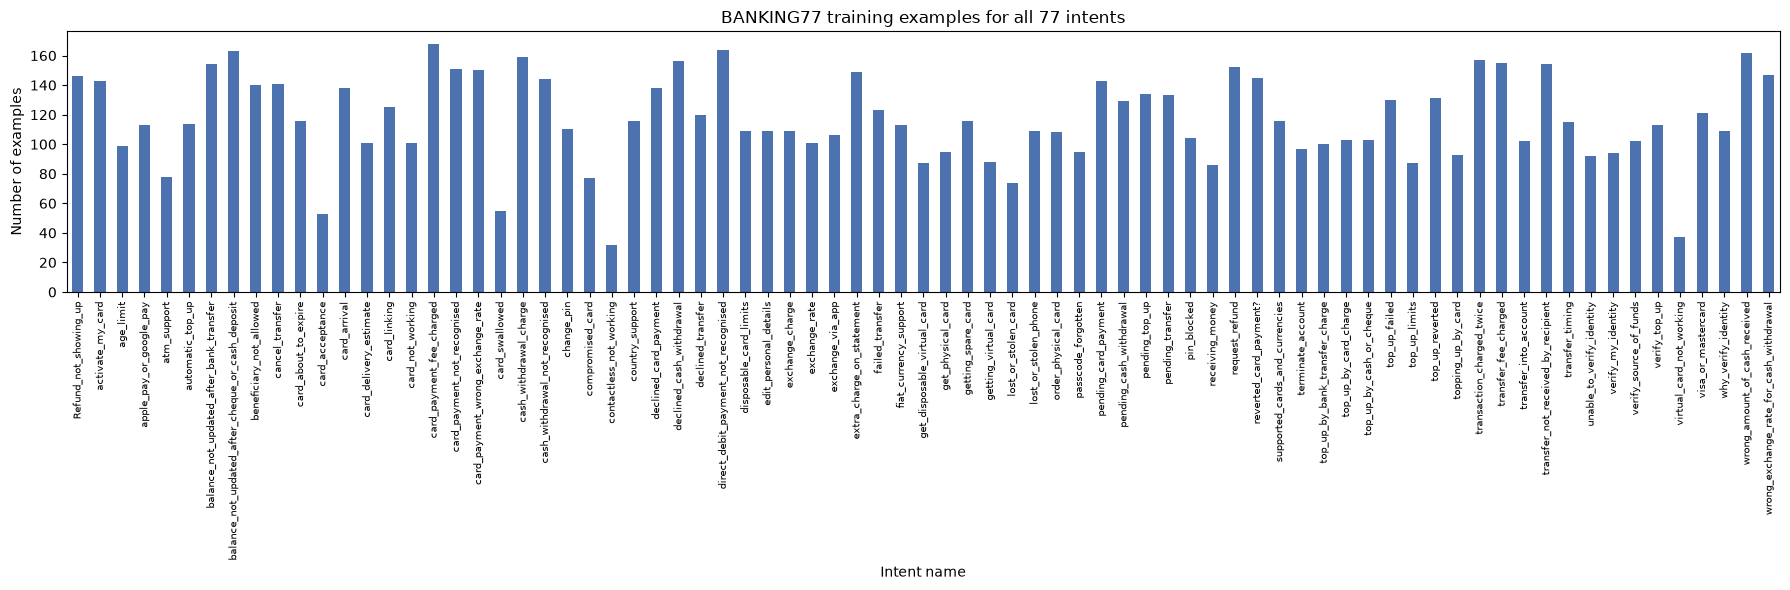

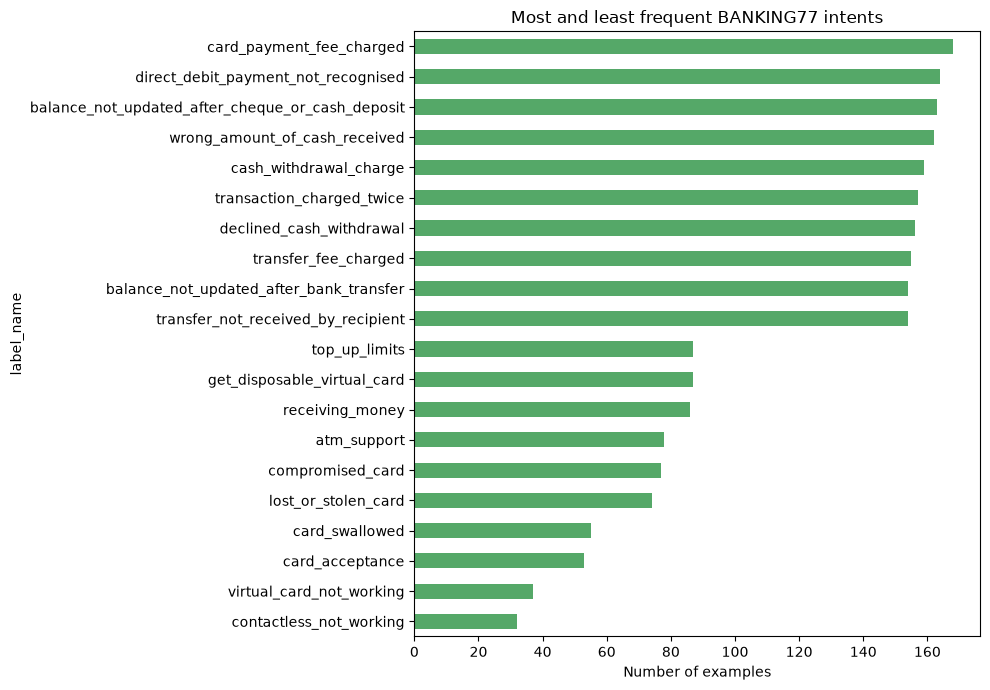

In [6]:
# The full plot is intentionally wide so every intent remains visible.
figures_dir = Path.cwd().parent / "figures"
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(18, 6))
label_counts.sort_index().plot(kind="bar", color="#4C72B0")
plt.title("BANKING77 training examples for all 77 intents")
plt.xlabel("Intent name")
plt.ylabel("Number of examples")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(figures_dir / "class_distribution_all_intents.png", dpi=150)
plt.show()
plt.close()

focused = pd.concat([label_counts.head(10), label_counts.tail(10)]).sort_values()
plt.figure(figsize=(10, 7))
focused.plot(kind="barh", color="#55A868")
plt.title("Most and least frequent BANKING77 intents")
plt.xlabel("Number of examples")
plt.tight_layout()
plt.savefig(figures_dir / "class_distribution_top_bottom.png", dpi=150)
plt.show()
plt.close()

## Step 2d — Analyse query length

**What this does:** calculates characters, words, and a simple token-like length for each training query.

**Why:** short customer queries are suitable for the chosen models, but unusually long examples may be truncated by the Transformer tokenizer.

       character_length  word_length  token_like_length
count           9002.00      9002.00            9002.00
mean              59.52        11.95              11.95
std               41.02         7.92               7.92
min               13.00         2.00               2.00
25%               36.00         7.00               7.00
50%               47.00        10.00              10.00
75%               64.00        13.00              13.00
max              433.00        79.00              79.00


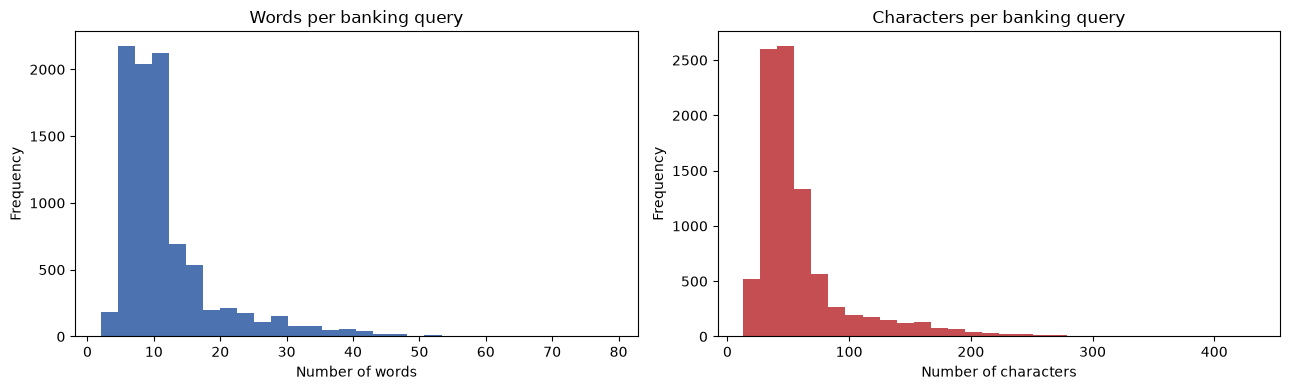

In [7]:
# These simple length measures make the later max_length choice easier to explain.
train["character_length"] = train["text"].str.len()
train["word_length"] = train["text"].str.split().str.len()
train["token_like_length"] = train["text"].str.split().str.len()
print(train[["character_length", "word_length", "token_like_length"]].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train["word_length"].plot(kind="hist", bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Words per banking query")
axes[0].set_xlabel("Number of words")
train["character_length"].plot(kind="hist", bins=30, ax=axes[1], color="#C44E52")
axes[1].set_title("Characters per banking query")
axes[1].set_xlabel("Number of characters")
plt.tight_layout()
plt.savefig(figures_dir / "query_length_histograms.png", dpi=150)
plt.show()
plt.close()

## Step 2e — Read representative examples

**What this does:** prints real examples from similar intent families.

**Why:** the later error analysis will focus on these semantic boundaries, such as pending versus failed transfers and card-arrival timing.

In [8]:
# Looking at examples helps us understand why some intents may be confused.
intent_groups = {
    "transfer_status": ["pending_transfer", "failed_transfer", "declined_transfer", "transfer_timing"],
    "card_arrival": ["card_arrival", "card_delivery_estimate"],
    "identity": ["why_verify_identity", "verify_my_identity", "unable_to_verify_identity"],
}

for group_name, intents in intent_groups.items():
    print(f"\n### {group_name}")
    for intent in intents:
        examples = train.loc[train["label_name"] == intent, "text"].head(2).tolist()
        print(f"\n{intent}:")
        for example in examples:
            print("-", example)


### transfer_status

pending_transfer:
- How long is the wait for a money transfer to show up?
- How long will the transfer take?

failed_transfer:
- Why can I not make a transfer?
- I don't think my transfer wen through. Why?

declined_transfer:
- Tell me why my transfer was declined.
- I tried to buy something online yesterday and got a message saying declined. I tried again today and got the same message. What's the problem?

transfer_timing:
- What are the time frames for the money to be available in my account?
- I need some money transferred ASAP, how long does the process take?

### card_arrival

card_arrival:
- how can i track card you sent
- What's the tracking on the card you sent?

card_delivery_estimate:
- Is there a specific date i can have it delivered?
- How long does it take for the card to come?

### identity

why_verify_identity:
- I answered so many questions about my identity. Why do you need this info?
- How does identity check work?

verify_my_identity:
- For the